# Counterfactual "What-If" Explanations

**Health Analytics Society — Stroke Prevention Demo**

Instead of just outputting a risk score, this notebook demonstrates how the Streamlit app could answer:

> *"What would have to change to lower this person's risk?"*

We simulate **manual counterfactuals** — systematically perturbing each modifiable clinical feature for a set of realistic patient personas and measuring the resulting risk change. This reframes the tool from a passive risk calculator into a **prevention instrument**.

### Approach
Rather than using DiCE (requires TensorFlow/PyTorch backend and can be brittle on tabular data), we implement **manual counterfactual scanning** — for each modifiable feature, we ask: *"if this patient achieved the healthier value for this feature, how much would their risk drop?"* This is transparent, interpretable, and directly actionable.

### Personas
Five realistic patients are constructed to cover a range of risk profiles.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path('../../')
DATA_PATH = ROOT / 'data/raw/stroke_data.csv'
THRESHOLD = 0.30
RANDOM_STATE = 42

print('Ready.')

Ready.


## 1. Retrain the Baseline Pipeline

In [2]:
df = pd.read_csv(DATA_PATH)

LEAKAGE_COLS = ['General health condition', 'depression', 'Minutes sedentary activity']
TARGET_COL = 'stroke'
CODED_CATEGORICAL_COLS = [
    'gender', 'age', 'Race', 'Marital status', 'alcohol ', 'smoke',
    'sleep disorder', 'Health Insurance', 'diabetes', 'hypertension',
    'high cholesterol', 'Coronary Heart Disease', 'Body Mass Index',
]

drop_cols = [c for c in LEAKAGE_COLS if c in df.columns]
df_clean = df.drop(columns=drop_cols)
y = df_clean[TARGET_COL]
X = df_clean.drop(columns=[TARGET_COL])
cat_cols = [c for c in CODED_CATEGORICAL_COLS if c in X.columns]
num_cols = [c for c in X.columns if c not in cat_cols]

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

pipeline = Pipeline([
    ('preprocess', ColumnTransformer([
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', ohe)]), cat_cols),
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
    ])),
    ('model', LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced', C=0.1, random_state=RANDOM_STATE)),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
pipeline.fit(X_train, y_train)

def predict_risk(row_dict):
    """Get stroke risk probability for a patient defined as a dict of feature values."""
    df_row = pd.DataFrame([row_dict])
    prob = pipeline.predict_proba(df_row)[0][1]
    return round(float(prob), 4)

print('Model trained. predict_risk() ready.')

Model trained. predict_risk() ready.


## 2. Define Patient Personas

Each persona is a realistic patient. Feature values use the same coding as the raw dataset.

In [3]:
# Column reference:
#   gender: 1=Male, 2=Female
#   age: 1=20-39, 2=40-59, 3=60+
#   Race: 1=Mex. Am., 2=Other Hisp., 3=NH White, 4=NH Black, 5=Other
#   Marital status: 1=Married, 2=Widowed, 3=Divorced, 4=Separated, 5=Never married, 6=Partner
#   alcohol : 0=No, 1=Yes  (note trailing space in column name)
#   smoke: 0=No, 1=Yes
#   sleep disorder: 1=Yes, 2=No
#   Health Insurance: 1=Yes, 2=No
#   diabetes: 0=No, 1=Yes
#   hypertension: 0=No, 1=Yes
#   high cholesterol: 0=No, 1=Yes
#   Coronary Heart Disease: 0=No, 1=Yes  (used as feature in baseline model)
#   Body Mass Index: 1=Underweight, 2=Normal, 3=Overweight, 4=Obese

BASE_NUMERIC = {
    'sleep time': 7,
    'Waist Circumference': 90.0,
    'Systolic blood pressure': 120,
    'Diastolic blood pressure': 80,
    'Fasting Glucose': 5.0,
    'Glycohemoglobin': 5.7,
    'energy': 2000,
    'protein': 60.0,
    'Carbohydrate': 250.0,
    'Dietary fiber': 25.0,
    'High-density lipoprotein': 1.3,
    'Triglyceride': 1.5,
    'Low-density lipoprotein': 2.8,
    'Total saturated fatty acids': 20.0,
    'Total monounsaturated fatty acids': 25.0,
    'Total polyunsaturated fatty acids': 15.0,
    'Potassium': 3500,
    'Sodium': 2300,
    'Total fat': 65.0,
}

personas = {
    'Maria, 52 F — Uncontrolled HTN': {
        'gender': 2, 'age': 2, 'Race': 1, 'Marital status': 1,
        'alcohol ': 0, 'smoke': 0, 'sleep disorder': 2, 'Health Insurance': 1,
        'diabetes': 0, 'hypertension': 1, 'high cholesterol': 1, 'Coronary Heart Disease': 0,
        'Body Mass Index': 3,
        'sleep time': 6, 'Waist Circumference': 98, 'Systolic blood pressure': 158,
        'Diastolic blood pressure': 95, 'Fasting Glucose': 5.8, 'Glycohemoglobin': 6.0,
        **{k: v for k, v in BASE_NUMERIC.items() if k not in ['sleep time', 'Waist Circumference',
           'Systolic blood pressure', 'Diastolic blood pressure', 'Fasting Glucose', 'Glycohemoglobin']}
    },
    'James, 64 M — Diabetic Smoker': {
        'gender': 1, 'age': 3, 'Race': 4, 'Marital status': 3,
        'alcohol ': 1, 'smoke': 1, 'sleep disorder': 1, 'Health Insurance': 2,
        'diabetes': 1, 'hypertension': 1, 'high cholesterol': 1, 'Coronary Heart Disease': 0,
        'Body Mass Index': 4,
        'sleep time': 5, 'Waist Circumference': 112, 'Systolic blood pressure': 148,
        'Diastolic blood pressure': 90, 'Fasting Glucose': 9.2, 'Glycohemoglobin': 8.1,
        **{k: v for k, v in BASE_NUMERIC.items() if k not in ['sleep time', 'Waist Circumference',
           'Systolic blood pressure', 'Diastolic blood pressure', 'Fasting Glucose', 'Glycohemoglobin']}
    },
    'Linda, 47 F — Borderline, Uninsured': {
        'gender': 2, 'age': 2, 'Race': 2, 'Marital status': 5,
        'alcohol ': 0, 'smoke': 0, 'sleep disorder': 2, 'Health Insurance': 2,
        'diabetes': 0, 'hypertension': 0, 'high cholesterol': 1, 'Coronary Heart Disease': 0,
        'Body Mass Index': 3,
        'sleep time': 6, 'Waist Circumference': 95, 'Systolic blood pressure': 132,
        'Diastolic blood pressure': 84, 'Fasting Glucose': 6.4, 'Glycohemoglobin': 5.9,
        **{k: v for k, v in BASE_NUMERIC.items() if k not in ['sleep time', 'Waist Circumference',
           'Systolic blood pressure', 'Diastolic blood pressure', 'Fasting Glucose', 'Glycohemoglobin']}
    },
    'Robert, 68 M — Multi-morbid': {
        'gender': 1, 'age': 3, 'Race': 3, 'Marital status': 1,
        'alcohol ': 1, 'smoke': 1, 'sleep disorder': 1, 'Health Insurance': 1,
        'diabetes': 1, 'hypertension': 1, 'high cholesterol': 1, 'Coronary Heart Disease': 1,
        'Body Mass Index': 4,
        'sleep time': 5, 'Waist Circumference': 118, 'Systolic blood pressure': 165,
        'Diastolic blood pressure': 98, 'Fasting Glucose': 10.5, 'Glycohemoglobin': 9.2,
        **{k: v for k, v in BASE_NUMERIC.items() if k not in ['sleep time', 'Waist Circumference',
           'Systolic blood pressure', 'Diastolic blood pressure', 'Fasting Glucose', 'Glycohemoglobin']}
    },
    'Aisha, 38 F — Low Risk Baseline': {
        'gender': 2, 'age': 1, 'Race': 4, 'Marital status': 1,
        'alcohol ': 0, 'smoke': 0, 'sleep disorder': 2, 'Health Insurance': 1,
        'diabetes': 0, 'hypertension': 0, 'high cholesterol': 0, 'Coronary Heart Disease': 0,
        'Body Mass Index': 2,
        'sleep time': 8, 'Waist Circumference': 78, 'Systolic blood pressure': 112,
        'Diastolic blood pressure': 72, 'Fasting Glucose': 4.8, 'Glycohemoglobin': 5.3,
        **{k: v for k, v in BASE_NUMERIC.items() if k not in ['sleep time', 'Waist Circumference',
           'Systolic blood pressure', 'Diastolic blood pressure', 'Fasting Glucose', 'Glycohemoglobin']}
    },
}

# Baseline risks
print('=== Baseline Risk Scores ===')
for name, p in personas.items():
    risk = predict_risk(p)
    label = 'HIGH RISK ⚠' if risk >= THRESHOLD else 'low risk ✓'
    print(f'  {name:<38} {risk*100:.1f}%  [{label}]')

=== Baseline Risk Scores ===
  Maria, 52 F — Uncontrolled HTN         25.1%  [low risk ✓]
  James, 64 M — Diabetic Smoker          63.5%  [HIGH RISK ⚠]
  Linda, 47 F — Borderline, Uninsured    18.4%  [low risk ✓]
  Robert, 68 M — Multi-morbid            78.5%  [HIGH RISK ⚠]
  Aisha, 38 F — Low Risk Baseline        12.6%  [low risk ✓]


## 3. Modifiable Feature Definitions

We define the "target healthy value" for each modifiable feature. Non-modifiable features (age, race, sex) are excluded from counterfactual scanning.

In [4]:
# Format: feature -> (healthy_target_value, human_readable_description)
# For categorical: the code for the healthier category
# For numeric: a specific improved value

MODIFIABLE_FEATURES = [
    # Categorical interventions
    ('smoke',              0,     'Quit smoking'),
    ('alcohol ',           0,     'Reduce alcohol use'),
    ('sleep disorder',     2,     'Treat sleep disorder'),
    ('hypertension',       0,     'Control blood pressure (medication/lifestyle)'),
    ('diabetes',           0,     'Manage diabetes to controlled range'),
    ('high cholesterol',   0,     'Control cholesterol'),
    ('Body Mass Index',    2,     'Reach healthy BMI (18.5–24.9)'),
    # Numeric interventions
    ('Systolic blood pressure',  120,  'Lower systolic BP to 120 mmHg'),
    ('Diastolic blood pressure',  80,  'Lower diastolic BP to 80 mmHg'),
    ('Fasting Glucose',          5.0,  'Normalize fasting glucose (<5.6 mmol/L)'),
    ('Glycohemoglobin',          5.7,  'Reduce HbA1c to normal range (<5.7%)'),
    ('sleep time',               8.0,  'Get 8 hours of sleep per night'),
    ('Dietary fiber',           30.0,  'Increase dietary fiber to 30g/day'),
    ('Sodium',                2300.0,  'Reduce sodium to 2300mg/day'),
    ('Waist Circumference',    88.0,   'Reduce waist circumference to <88 cm'),
]

print(f'Defined {len(MODIFIABLE_FEATURES)} modifiable interventions.')

Defined 15 modifiable interventions.


## 4. Counterfactual Scanner

In [5]:
def scan_counterfactuals(patient_dict, modifiable_features, threshold=THRESHOLD):
    """
    For each modifiable feature, compute:
      - baseline_risk: current prediction
      - counterfactual_risk: prediction if this ONE feature is changed to its healthy value
      - risk_drop: baseline - counterfactual (positive = reduction)
    Only reports features where the patient isn't already at the healthy value.
    Returns a DataFrame sorted by risk_drop descending.
    """
    baseline_risk = predict_risk(patient_dict)
    results = []

    for feat, healthy_val, description in modifiable_features:
        if feat not in patient_dict:
            continue
        current_val = patient_dict[feat]

        # Skip if already at or better than healthy value
        if isinstance(healthy_val, (int, float)):
            if feat in ['Systolic blood pressure', 'Diastolic blood pressure',
                        'Fasting Glucose', 'Glycohemoglobin', 'Waist Circumference', 'Sodium']:
                # Lower is better — skip if already at or below target
                if current_val <= healthy_val:
                    continue
            elif feat in ['sleep time', 'Dietary fiber']:
                # Higher is better — skip if already at or above target
                if current_val >= healthy_val:
                    continue
        else:
            if current_val == healthy_val:
                continue

        # Apply the intervention
        cf_patient = dict(patient_dict)
        cf_patient[feat] = healthy_val
        cf_risk = predict_risk(cf_patient)
        risk_drop = baseline_risk - cf_risk

        results.append({
            'intervention': description,
            'feature': feat,
            'current_value': current_val,
            'target_value': healthy_val,
            'baseline_risk': baseline_risk,
            'counterfactual_risk': cf_risk,
            'risk_drop': risk_drop,
            'risk_drop_pct': risk_drop * 100,
        })

    df_out = pd.DataFrame(results).sort_values('risk_drop', ascending=False)
    return baseline_risk, df_out


print('scan_counterfactuals() defined.')

scan_counterfactuals() defined.


## 5. Streamlit-Style Output Simulation

The following function formats output exactly as the Streamlit app would display it — risk score, badge, and intervention recommendations ordered by impact.

In [6]:
def streamlit_card(patient_name, patient_dict, top_n=5):
    """
    Simulate the Streamlit app output for a given patient.
    Shows: risk score, badge, and counterfactual what-if table.
    """
    baseline_risk, cf_df = scan_counterfactuals(patient_dict, MODIFIABLE_FEATURES)
    risk_pct = baseline_risk * 100
    badge = '⚠️  HIGH RISK' if baseline_risk >= THRESHOLD else '✅  LOW RISK'

    bar = '█' * int(risk_pct / 5) + '░' * (20 - int(risk_pct / 5))

    print('=' * 60)
    print(f'  🧠 Stroke Prevention Demo')
    print(f'  Patient: {patient_name}')
    print('=' * 60)
    print(f'  Stroke Risk Score:  {risk_pct:.1f}%')
    print(f'  [{bar}]')
    print(f'  {badge}')
    print(f'  (Threshold: {THRESHOLD*100:.0f}% · Model output)')
    print()

    if cf_df.empty:
        print('  ✅ All modifiable risk factors are already at healthy targets.')
        print()
        return

    top = cf_df[cf_df['risk_drop'] > 0].head(top_n)
    if top.empty:
        print('  No single intervention produces meaningful risk reduction.')
        print()
        return

    print('  💡 What-If Interventions (single change, highest impact first):')
    print(f'  {"Intervention":<45} {"→ Risk drops to":<18} {"Reduction"}')
    print('  ' + '-' * 70)
    for _, row in top.iterrows():
        arrow = '↓' if row['risk_drop'] > 0 else '↑'
        print(f"  {row['intervention']:<45} {row['counterfactual_risk']*100:>6.1f}%           "
              f"{arrow} {abs(row['risk_drop_pct']):.1f}pp")
    print()

    # Best combined scenario (all interventions that help)
    best_combo_patient = dict(patient_dict)
    for _, row in cf_df[cf_df['risk_drop'] > 0].iterrows():
        best_combo_patient[row['feature']] = row['target_value']
    best_risk = predict_risk(best_combo_patient)
    total_drop = (baseline_risk - best_risk) * 100
    print(f'  🎯 Best case (all interventions combined):')
    print(f'     Risk drops from {risk_pct:.1f}% → {best_risk*100:.1f}% (↓{total_drop:.1f}pp)')
    print('=' * 60)
    print()


print('streamlit_card() defined.')

streamlit_card() defined.


## 6. Run All Personas

In [7]:
for name, patient in personas.items():
    streamlit_card(name, patient, top_n=5)

  🧠 Stroke Prevention Demo
  Patient: Maria, 52 F — Uncontrolled HTN
  Stroke Risk Score:  25.1%
  [█████░░░░░░░░░░░░░░░]
  ✅  LOW RISK
  (Threshold: 30% · Model output)

  💡 What-If Interventions (single change, highest impact first):
  Intervention                                  → Risk drops to    Reduction
  ----------------------------------------------------------------------
  Control blood pressure (medication/lifestyle)   15.0%           ↓ 10.1pp
  Control cholesterol                             19.5%           ↓ 5.6pp
  Lower systolic BP to 120 mmHg                   19.6%           ↓ 5.5pp
  Increase dietary fiber to 30g/day               24.1%           ↓ 1.0pp
  Normalize fasting glucose (<5.6 mmol/L)         24.6%           ↓ 0.5pp

  🎯 Best case (all interventions combined):
     Risk drops from 25.1% → 7.9% (↓17.2pp)

  🧠 Stroke Prevention Demo
  Patient: James, 64 M — Diabetic Smoker
  Stroke Risk Score:  63.5%
  [████████████░░░░░░░░]
  ⚠️  HIGH RISK
  (Threshold: 30

## 7. Visualization: Counterfactual Impact Chart

A horizontal bar chart showing how much each intervention reduces risk for the highest-risk patient — the format most naturally suited for the Streamlit sidebar.

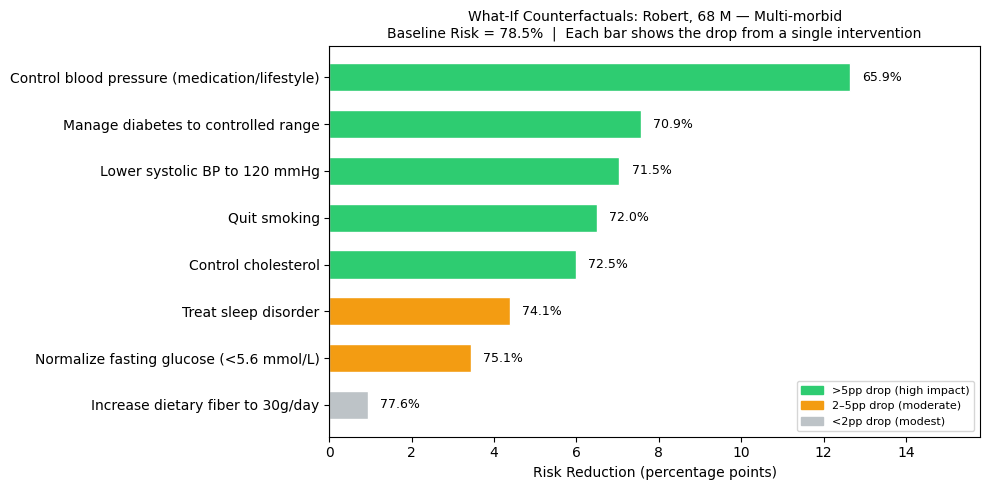

Saved: counterfactual_impact_chart.png


In [8]:
# Pick the highest-risk persona for visualization
target_name = 'Robert, 68 M — Multi-morbid'
target_patient = personas[target_name]
baseline_risk, cf_df = scan_counterfactuals(target_patient, MODIFIABLE_FEATURES)

positive_cf = cf_df[cf_df['risk_drop'] > 0].head(10)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2ecc71' if d > 5 else '#f39c12' if d > 2 else '#bdc3c7'
          for d in positive_cf['risk_drop_pct']]

bars = ax.barh(positive_cf['intervention'][::-1], positive_cf['risk_drop_pct'][::-1],
               color=colors[::-1], edgecolor='white', height=0.6)

for bar, (_, row) in zip(bars, positive_cf[::-1].iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{row['counterfactual_risk']*100:.1f}%", va='center', ha='left', fontsize=9)

ax.set_xlabel('Risk Reduction (percentage points)', fontsize=10)
ax.set_title(f'What-If Counterfactuals: {target_name}\nBaseline Risk = {baseline_risk*100:.1f}%  |  Each bar shows the drop from a single intervention',
             fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(0, positive_cf['risk_drop_pct'].max() * 1.25)

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='>5pp drop (high impact)'),
    mpatches.Patch(color='#f39c12', label='2–5pp drop (moderate)'),
    mpatches.Patch(color='#bdc3c7', label='<2pp drop (modest)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('counterfactual_impact_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: counterfactual_impact_chart.png')

## 8. Threshold Sensitivity: At What Risk Score Does Each Persona Cross the Threshold?

In [9]:
print('=== Counterfactuals That Would Drop a Patient Below the Risk Threshold ===')
print(f'(Threshold = {THRESHOLD*100:.0f}%)\n')

for name, patient in personas.items():
    baseline_risk, cf_df = scan_counterfactuals(patient, MODIFIABLE_FEATURES)
    if baseline_risk < THRESHOLD:
        print(f'  {name}: Already below threshold ({baseline_risk*100:.1f}%) ✅')
        continue

    threshold_crossers = cf_df[cf_df['counterfactual_risk'] < THRESHOLD]
    if threshold_crossers.empty:
        print(f'  {name}: No single intervention drops below threshold (baseline {baseline_risk*100:.1f}%)')
    else:
        print(f'  {name}: (baseline {baseline_risk*100:.1f}%) — interventions that cross to low-risk:')
        for _, row in threshold_crossers.iterrows():
            print(f"    → {row['intervention']:<48} risk → {row['counterfactual_risk']*100:.1f}%")
    print()

=== Counterfactuals That Would Drop a Patient Below the Risk Threshold ===
(Threshold = 30%)

  Maria, 52 F — Uncontrolled HTN: Already below threshold (25.1%) ✅
  James, 64 M — Diabetic Smoker: No single intervention drops below threshold (baseline 63.5%)

  Linda, 47 F — Borderline, Uninsured: Already below threshold (18.4%) ✅
  Robert, 68 M — Multi-morbid: No single intervention drops below threshold (baseline 78.5%)

  Aisha, 38 F — Low Risk Baseline: Already below threshold (12.6%) ✅


## 9. Streamlit Integration Notes

This notebook demonstrates what the Streamlit app *could* show. To integrate into the live app:

**Add to `app/streamlit_app.py`:**
```python
# After computing `probability`:
st.subheader('💡 What-If: How Could This Risk Be Lowered?')

MODIFIABLE = [
    ('smoke',              0,   'Quit smoking'),
    ('hypertension',       0,   'Control blood pressure'),
    ('Systolic blood pressure', 120, 'Lower systolic BP to 120 mmHg'),
    ('Fasting Glucose',    5.0, 'Normalize fasting glucose'),
    ('Glycohemoglobin',    5.7, 'Reduce HbA1c'),
    # ... etc
]

counterfactuals = []
for feat, target, description in MODIFIABLE:
    if feat in user_inputs and user_inputs[feat] != target:
        cf_input = dict(user_inputs)
        cf_input[feat] = target
        cf_prob = model.predict_proba(pd.DataFrame([cf_input]))[0][1]
        drop = probability - cf_prob
        if drop > 0:
            counterfactuals.append((description, cf_prob, drop))

counterfactuals.sort(key=lambda x: -x[2])
for desc, cf_prob, drop in counterfactuals[:4]:
    st.markdown(f'- **{desc}**: risk drops from {probability*100:.1f}% → {cf_prob*100:.1f}% ↓{drop*100:.1f}pp')
```

**Key design decision:** Show only interventions with >1pp drop to avoid cluttering the UI with noise.

**Disclaimer language to add:**
> *These what-if estimates reflect model predictions only. They are not medical advice. Lifestyle and medication changes should always be discussed with a healthcare provider.*